### Bonus Solution: Behind Pytorch Autograd

In [21]:
# Seting up the environment and importing necessary libraries

from graphviz import Digraph
import torch
from torch import nn
from torch.autograd import Variable

For Task 1, the network is a simple linear layer with no bias terms, so we can easily evaluate the gradients:

$$
\frac{\partial L}{\partial \mathbf{\hat{y}}} = \mathbf{\hat{y}} - \mathbf{y} =
\begin{bmatrix}
0.55 \\
0.85
\end{bmatrix}
-
\begin{bmatrix}
1 \\
2
\end{bmatrix}
=
\begin{bmatrix}
-0.45 \\
-1.15
\end{bmatrix}
$$

$$
\frac{\partial L}{\partial \mathbf{W}}
=
\frac{\partial \mathbf{\hat{y}}}{\partial \mathbf{W}}
\cdot
\left( \frac{\partial L}{\partial \mathbf{\hat{y}}} \right)^{\top}
=
\begin{bmatrix}
1 \\
2
\end{bmatrix}
\begin{bmatrix}
-0.45 & -1.15
\end{bmatrix}
=
\begin{bmatrix}
-0.45 & -1.15 \\
-0.9 & -2.3
\end{bmatrix}
$$

We can observe that `Input` is exactly the weight gradient and `Output` is exactly the output gradient of the
hooked layer (the linear layer). The first entry of `Input` is `None` because that’s supposed to be the input
gradient, but we do not have to compute the input gradient for the first layer.

For Task 2, we have to first read the Pytorch documentation of class `torch.autograd.graph.Node`. There
is a table showing all the fields available. `name` and `metadata` sound too generic, `register_hook` and
`register_prehook` have already been introduced in Tasks 1-2, and `increment_version` doesn’t sound
useful here. This leaves us with the suspiciously poorly documented field: `next_functions`. You can click
in and notice there’s still no meaningful documentation there. Maybe that’s what we are looking for!

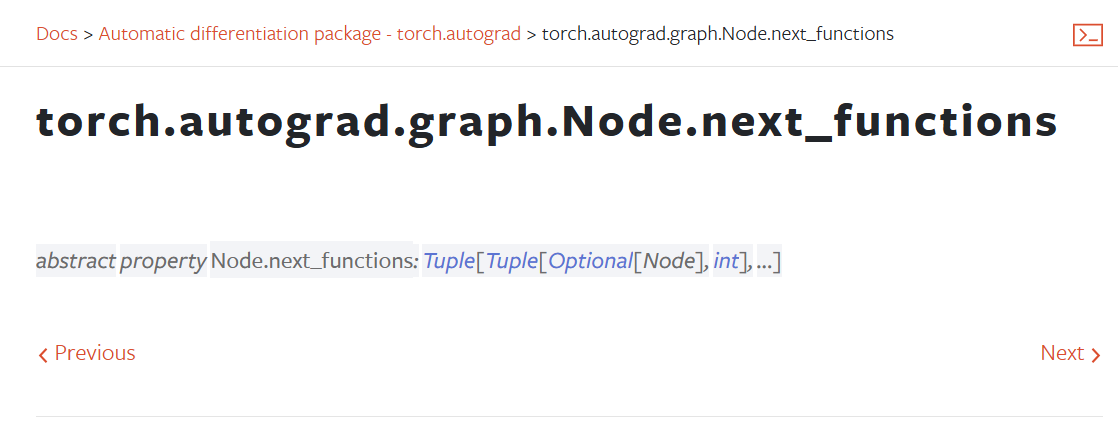

There is no documentation but fortunately, the type is clearly specified. It’s most likely a `Tuple` of `Tuple`
(the inner layer contains an optional `Node` and an `int`). The outer layer is likely used like a “list” of edges,
and each entry will contain a `Node` or `None` (we don’t have to care about what the `int` means). This leads
us to the following traversal function:

In [22]:
def visualize_autograd_graph(loss):
    """ Produces a visualization of PyTorch autograd graph """    

    node_attr = dict(style='filled',
                     shape='box',
                     align='left',
                     fontsize='12',
                     ranksep='0.1',
                     height='0.2')
    dot = Digraph(node_attr=node_attr, graph_attr=dict(size="12,12"))
    visited = set()

    """ Helper functions """

    def size_to_str(size):
        return '('+(', ').join(['%d'% v for v in size])+')'

    def create_parameter_node(var, size):
        dot.node(str(id(var)), size_to_str(size), fillcolor='lightblue')

    def create_func_node(var):
        dot.node(str(id(var)), str(type(var).__name__))

    def create_edge(u, v):
        dot.edge(str(id(u)), str(id(v)))

    def add_nodes(var):
        if var in visited:
            return
        visited.add(var)

        if hasattr(var, 'variable'):
            create_parameter_node(var, var.variable.size())
        else:
            create_func_node(var)

        if hasattr(var, 'next_functions'):
            for e in var.next_functions:  # iterate over the outgoing edges
                if e[0] is not None:      # e is a tuple, e[0] can be Node or None
                    create_edge(e[0], var)
                    add_nodes(e[0])       # traverse recursively
        pass

    add_nodes(loss.grad_fn)
    return dot



In [23]:
# Sample test case

# Sample neural network with 2 linear layers
class TwoLayerNet(nn.Module):
    def __init__(self, D_in, H, D_out):
        super(TwoLayerNet, self).__init__()
        self.linear1 = nn.Linear(D_in, H)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(H, D_out)

    def forward(self, x):
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)
        return x

model = TwoLayerNet(1000, 100, 10)
loss = nn.MSELoss()

# Forward propagation
x = torch.randn(64, 1000)  # Random input data
y = torch.randn(64, 10)  # Random target data
y_pred = model(x) 
output = loss(y, y_pred)

# Visualize the gradient graph
dot = visualize_autograd_graph(output)

assert len(list(filter(lambda x: 'Backward' in x, dot.body))) == 6, \
    "Incorrect number of internal nodes"
assert len(list(filter(lambda x: 'lightblue' in x, dot.body))) == 4, \
    "Incorrect number of tensors"
assert len(list(filter(lambda x: '->' in x, dot.body))) == 9, \
    "Incorrect number of edges"

print("Sample test case passed, congratulations!")

Sample test case passed, congratulations!


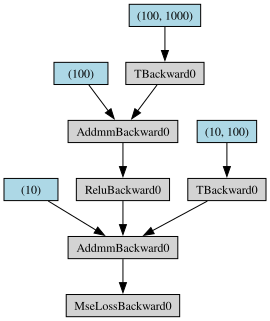

In [24]:
# Run this to visualize the autograd graph
dot

<div style="
    border-left: 6px solid #3b82f6;
    background-color: #eff6ff;
    padding: 12px;
    border-radius: 6px;
    margin: 10px 0;
">
<b>ℹ️ Question: Why is it so poorly documented?</b><br>
This field is only used in Pytorch internally – since only the autograd engine traverses this graph under
the hood during backward propagation. Perhaps they didn’t feel the need to explain this to the users
of this library...
</div>

For Task3, the main idea is to have two edges pointing to the same autograd node in the graph – intuitively,
this happens if a tensor is used twice at different places. Hopefully, this reminds you of **skip connections**
we discussed in tutorial, where the output of an earlier hidden layer is added to the output of a later layer.
During back propagation, the output gradient will hence propagate to both the current hidden layer and
the earlier layer as well.

We can construct a simple skip connection using a model with 2 linear layers:

In [25]:
class HackNet(nn.Module):
    def __init__(self):
        super(HackNet, self).__init__()
        self.linear1 = nn.Linear(10, 10)
        self.linear2 = nn.Linear(10, 10)

    def forward(self, x):
        x1 = self.linear1(x)
        x2 = self.linear2(x1)
        x2 += x1
        return x2

In [ ]:
model = HackNet()
loss = nn.MSELoss()

x = torch.randn(64, 10)
y = torch.randn(64, 10)
y_pred = model(x)
output = loss(y, y_pred)

visualize_autograd_graph(output)

The resulting autograd graph is shown on the left. If we skip the visited memory, then the output would
be a wrong one – shown on the right. (Actually, the behaviour for duplicate labels is undefined, so you
might get a different output.)

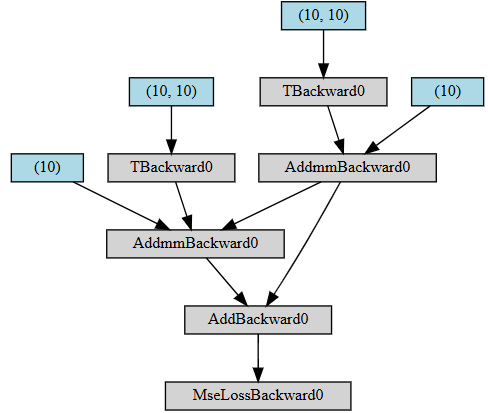 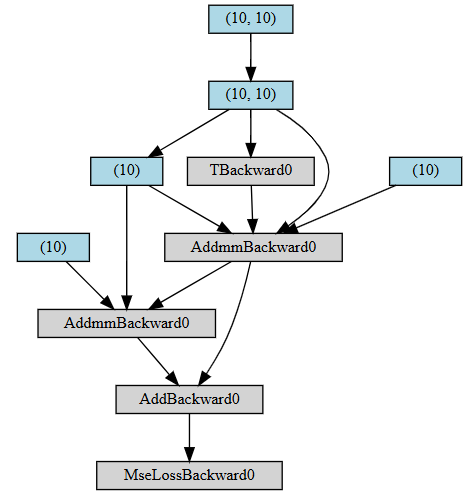

**Reference:** The boilerplate code for Task 2 is adapted from [Torchviz Example – Kaggle](https://www.kaggle.com/code/ehsanmjz/torchviz-example).  
